In [1]:
from src.analyse_equations.analyse_equations import add_all_data_error, print_units_of_one_equation
from src.analyse_equations.analyse_equations import set_pandas_options, create_error_table
from src.analyse_equations.analyse_equations import add_n_fold_error

from src.analyse_equations.add_information_to_equations import add_proposed_equations

from src.analyse_equations.plot_error_per_system import plot_error_per_system
from src.analyse_equations.plot_predictions_of_one_equation import plot_prediction
from src.analyse_equations.utils import save_proposed_equation, get_data_folds, load_proposed_equations

from src.equation_discovery.config_equations_for_each_dataset import ConfigEquationDiscovery
from src.equation_discovery.evaluate_equation import map_equation_to_syntax_tree

from src.preprocess_data.preprocess_data import prepare_dataset, get_unit_dict
from src.analyse_equations.config_analyse_equations import ConfigPlotBestEquation
from src.preprocess_data.config_load_dataset import ConfigLoadData
from src.SyntaxTree.src.syntax_tree.config_syntax_tree import ConfigSyntaxTree
from src.utils.config_hyperparameter import ConfigHyperparameter
import logging
from src.analyse_equations.create_constant_table import create_constant_table
from src.analyse_equations.plot_abs_difference_between_equation import abs_difference_between_equation
from src.analyse_equations.plot_histogram_for_features import histogram_for_features
from src.analyse_equations.plot_error_per_system import heatmap_error_per_system, save_system_error_heatmap
from src.analyse_equations.create_constant_table import save_constant_table
from matplotlib import pyplot as plt
import matplotlib

# Configs

In [2]:
logger = logging.getLogger(__name__)
set_pandas_options()

parser = ConfigHyperparameter.arguments_parser()
parser = ConfigLoadData.arguments_parser(parser)
parser = ConfigEquationDiscovery.arguments_parser(parser)
parser = ConfigPlotBestEquation.arguments_parser(parser)
parser = ConfigSyntaxTree.arguments_parser(parser)
args, unknown = parser.parse_known_args()
args.save_path = args.ROOT_DIR / f'results/{args.save_set_folder}/equation_set_{args.exp_name}.json'
args.unit_dict = get_unit_dict(args)
args.unit_dict['y'] = args.unit_dict[args.target]
args.unit_dimension = 5
measurement_error_dic = {
    'drop_length': 0.000042,
    'adv': 0.07696902,
    'rec': 0.03298672,
    'avg_vel': 0.0021,
    'width': 0.00005,
    'y_center':0.000003,
    'middle_angle': 0.03141593,
    'x_center': 0.0000042,
    'static_adv': 0.01570796,
    'static_rec': 0.01570796
}
logging.basicConfig(level=logging.INFO)


# Results to load

In [3]:
proposed_equations = load_proposed_equations(args)
add_proposed_equations(args, proposed_equations)

#files_test, files_train = get_train_test_files(args, proposed_equations)
folds_dict = get_data_folds(args, proposed_equations)
all_files = []
for excel_name, files in folds_dict.items():
    all_files.extend(files)

Load proposed equations from: /home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/results/Sajjad_Smoothed/equation_set_ID_error_per_dataset.json
Loading 0/11 results from: results/Sajjad_Smoothed/02_Jun_2025_23:47:32_best_models_NGED.json
Loading 1/11 results from: results/Sajjad/04_Apr_2025_09:07:37_best_models_1c_50_interations.json
Loading 2/11 results from: results/Xiaomei/28_Mär_2025_11:41:26_best_models_1c_50_interations.json
Loading 3/11 results from: results/Xiaomei/28_Mär_2025_12:07:31_best_models_1c_50_interations.json
Loading 4/11 results from: results/Xiaomei/01_Apr_2025_17:12:42_best_models_1c_50_interations.json
Loading 5/11 results from: results/Xiaomei/01_Apr_2025_18:10:55_best_models_1c_50_interations.json
Loading 6/11 results from: results/Xiaomei/01_Apr_2025_20:15:19_best_models_1c_50_interations.json
Loading 7/11 results from: results/Xiaomei/01_Apr_2025_20:45:29_best_models_1c_50_interations.json
Loading 8/11 results from: results/Xiaomei/02_Apr_2025_18:

# Cross Validation

In [4]:
filtered_dfs_test, filtered_dfs_train, tree = add_n_fold_error(args, folds_dict, measurement_error_dic, proposed_equations)
save_proposed_equation(args, folds_dict, proposed_equations)

INFO:src.analyse_equations.analyse_equations:Fold 0
INFO:src.analyse_equations.analyse_equations:Fold 1
INFO:src.analyse_equations.analyse_equations:Fold 2
INFO:src.analyse_equations.analyse_equations:Equations removed cause of Unit Error: 216
INFO:src.analyse_equations.analyse_equations:Equations removed cause of MaxDepthError: 0
INFO:src.analyse_equations.analyse_equations:Equations removed cause of Overflow: 0
INFO:src.analyse_equations.analyse_equations:Equations removed cause of other Error: 25
INFO:src.analyse_equations.analyse_equations:Equations kept : 353


Proposed Equations are saved to: /home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/results/Sajjad_Smoothed/equation_set_ID_error_per_dataset.json


# Calculate Error over all data

In [5]:
all_data_dfs = prepare_dataset(args, all_files)
add_all_data_error(all_data_dfs, args, proposed_equations)

# Create error table

In [38]:
num_variables = 1
df_error = create_error_table(args, num_variables, proposed_equations, metric='error')
df_error

INFO:src.analyse_equations.analyse_equations:table with errors saved @/home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/plots/ID_error_per_dataset/table_with_equations_error.tex


                                                       equation                                                                                                                                        infix fold mean train error fold mean test error train all error error calc. std  rank
174                                  * c  / drop_length width                                                                                                ( c_0 * (  ( drop_length )  /  ( width )  )  )               8.94e-06             8.94e-06              9.00e-06  1.28e-06     0
4               + c * friction_coef * width * viscosity avg_vel                                               ( c_0 +  (  ( friction_coef )  * (  ( width )  * (  ( viscosity )  *  ( avg_vel )  )  )  )  )               9.15e-06             9.15e-06              9.20e-06  8.56e-07     1
87                        / drop_length  * c  * rec y_center                                                                             (  ( 

,equation,infix,fold mean train error,fold mean test error,train all error error,calc. std,rank
174,* c / drop_length width,( c_0 * ( ( drop_length ) / ( width ) ) ),8.94e-06,8.94e-06,9.00e-06,1.28e-06,0
4,+ c * friction_coef * width * viscosity avg_vel,( c_0 + ( ( friction_coef ) * ( ( width ) * ( ( viscosity ) * ( avg_vel ) ) ) ) ),9.15e-06,9.15e-06,9.20e-06,8.56e-07,1
87,/ drop_length * c * rec y_center,( ( drop_length ) / ( c_0 * ( ( rec ) * ( y_center ) ) ) ),9.18e-06,9.18e-06,9.21e-06,2.25e-07,2
29,* 2 * ** drop_length 2 + avg_vel c,( ( 2 ) * ( ( drop_length ) ** ( ( 2 ) ) * ( ( avg_vel ) + c_0 ) ) ),9.25e-06,9.25e-06,9.32e-06,1.38e-06,3
88,/ drop_length * c rec,( ( drop_length ) / ( c_0 * ( rec ) ) ),9.67e-06,9.67e-06,9.76e-06,1.70e-07,4
76,* c / drop_length rec,( c_0 * ( ( drop_length ) / ( rec ) ) ),9.67e-06,9.67e-06,9.76e-06,1.28e-06,5
33,* 3 * c ** drop_length 2,( ( 3 ) * ( c_0 * ( drop_length ) ** ( ( 2 ) ) ) ),9.71e-06,9.71e-06,9.79e-06,1.40e-06,6
34,* ** drop_length 2 + c 2,( ( drop_length ) ** ( ( 2 ) ) * ( c_0 + ( 2 ) ) ),9.71e-06,9.71e-06,9.79e-06,1.40e-06,7
39,* 4 * c ** drop_length 2,( ( 4 ) * ( c_0 * ( drop_length ) ** ( ( 2 ) ) ) ),9.71e-06,9.71e-06,9.79e-06,1.40e-06,8
40,* 2 * ** drop_length 2 + c 1,( ( 2 ) * ( ( drop_length ) ** ( ( 2 ) ) * ( c_0 + ( 1 ) ) ) ),9.71e-06,9.71e-06,9.79e-06,1.40e-06,9


In [40]:
num_variables = 1
df_error = create_error_table(args, num_variables, proposed_equations, metric='error_mse')
df_error

INFO:src.analyse_equations.analyse_equations:table with errors saved @/home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/plots/ID_error_per_dataset/table_with_equations_error_mse.tex


                                                       equation                                                                                                                                        infix fold mean train error_mse fold mean test error_mse train all error error_mse calc. std  rank
174                                  * c  / drop_length width                                                                                                ( c_0 * (  ( drop_length )  /  ( width )  )  )                   1.86e-10                 1.86e-10                  1.90e-10  1.28e-06     0
87                        / drop_length  * c  * rec y_center                                                                             (  ( drop_length )  / ( c_0 * (  ( rec )  *  ( y_center )  )  )  )                   2.01e-10                 2.01e-10                  2.02e-10  2.25e-07     1
4               + c * friction_coef * width * viscosity avg_vel                                           

,equation,infix,fold mean train error_mse,fold mean test error_mse,train all error error_mse,calc. std,rank
174,* c / drop_length width,( c_0 * ( ( drop_length ) / ( width ) ) ),1.86e-10,1.86e-10,1.90e-10,1.28e-06,0
87,/ drop_length * c * rec y_center,( ( drop_length ) / ( c_0 * ( ( rec ) * ( y_center ) ) ) ),2.01e-10,2.01e-10,2.02e-10,2.25e-07,1
4,+ c * friction_coef * width * viscosity avg_vel,( c_0 + ( ( friction_coef ) * ( ( width ) * ( ( viscosity ) * ( avg_vel ) ) ) ) ),2.03e-10,2.03e-10,2.07e-10,8.56e-07,2
29,* 2 * ** drop_length 2 + avg_vel c,( ( 2 ) * ( ( drop_length ) ** ( ( 2 ) ) * ( ( avg_vel ) + c_0 ) ) ),2.04e-10,2.04e-10,2.08e-10,1.38e-06,3
88,/ drop_length * c rec,( ( drop_length ) / ( c_0 * ( rec ) ) ),2.09e-10,2.09e-10,2.12e-10,1.70e-07,4
76,* c / drop_length rec,( c_0 * ( ( drop_length ) / ( rec ) ) ),2.09e-10,2.09e-10,2.12e-10,1.28e-06,5
175,* c * drop_length / sin rec rec,( c_0 * ( ( drop_length ) * ( sin ( ( rec ) ) / ( rec ) ) ) ),2.11e-10,2.11e-10,2.15e-10,1.81e-06,6
33,* 3 * c ** drop_length 2,( ( 3 ) * ( c_0 * ( drop_length ) ** ( ( 2 ) ) ) ),2.12e-10,2.12e-10,2.17e-10,1.40e-06,7
36,* ** drop_length 2 + * 2 c 1,( ( drop_length ) ** ( ( 2 ) ) * ( ( ( 2 ) * c_0 ) + ( 1 ) ) ),2.12e-10,2.12e-10,2.17e-10,1.40e-06,8
35,* 3 / ** drop_length 2 c,( ( 3 ) * ( ( drop_length ) ** ( ( 2 ) ) / c_0 ) ),2.12e-10,2.12e-10,2.17e-10,1.34e-07,9


In [41]:
num_variables = 1
df_error = create_error_table(args, num_variables, proposed_equations, metric='err_rel')
df_error

INFO:src.analyse_equations.analyse_equations:table with errors saved @/home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/plots/ID_error_per_dataset/table_with_equations_err_rel.tex


                                                       equation                                                                                                                                        infix fold mean train err_rel fold mean test err_rel train all error err_rel calc. std  rank
174                                  * c  / drop_length width                                                                                                ( c_0 * (  ( drop_length )  /  ( width )  )  )                 8.88e+03               8.88e+03                8.96e+03  1.28e-06     0
4               + c * friction_coef * width * viscosity avg_vel                                               ( c_0 +  (  ( friction_coef )  * (  ( width )  * (  ( viscosity )  *  ( avg_vel )  )  )  )  )                 9.09e+03               9.09e+03                9.14e+03  8.56e-07     1
29                    * 2  *  ** drop_length 2   + avg_vel c                                                            (  (

,equation,infix,fold mean train err_rel,fold mean test err_rel,train all error err_rel,calc. std,rank
174,* c / drop_length width,( c_0 * ( ( drop_length ) / ( width ) ) ),8.88e+03,8.88e+03,8.96e+03,1.28e-06,0
4,+ c * friction_coef * width * viscosity avg_vel,( c_0 + ( ( friction_coef ) * ( ( width ) * ( ( viscosity ) * ( avg_vel ) ) ) ) ),9.09e+03,9.09e+03,9.14e+03,8.56e-07,1
29,* 2 * ** drop_length 2 + avg_vel c,( ( 2 ) * ( ( drop_length ) ** ( ( 2 ) ) * ( ( avg_vel ) + c_0 ) ) ),9.16e+03,9.16e+03,9.21e+03,1.38e-06,2
87,/ drop_length * c * rec y_center,( ( drop_length ) / ( c_0 * ( ( rec ) * ( y_center ) ) ) ),9.26e+03,9.26e+03,9.32e+03,2.25e-07,3
39,* 4 * c ** drop_length 2,( ( 4 ) * ( c_0 * ( drop_length ) ** ( ( 2 ) ) ) ),9.62e+03,9.62e+03,9.69e+03,1.40e-06,4
33,* 3 * c ** drop_length 2,( ( 3 ) * ( c_0 * ( drop_length ) ** ( ( 2 ) ) ) ),9.62e+03,9.62e+03,9.69e+03,1.40e-06,5
40,* 2 * ** drop_length 2 + c 1,( ( 2 ) * ( ( drop_length ) ** ( ( 2 ) ) * ( c_0 + ( 1 ) ) ) ),9.62e+03,9.62e+03,9.69e+03,1.40e-06,6
34,* ** drop_length 2 + c 2,( ( drop_length ) ** ( ( 2 ) ) * ( c_0 + ( 2 ) ) ),9.62e+03,9.62e+03,9.69e+03,1.40e-06,7
38,* 4 / ** drop_length 2 c,( ( 4 ) * ( ( drop_length ) ** ( ( 2 ) ) / c_0 ) ),9.62e+03,9.62e+03,9.69e+03,1.33e-07,8
50,* ** c 2 ** drop_length 2,( c_0 ** ( ( 2 ) ) * ( drop_length ) ** ( ( 2 ) ) ),9.62e+03,9.62e+03,9.69e+03,1.03e-06,9


# Create constant table

In [7]:
index = 174
create_constant_table( all_data_dfs,
        args,
        df_error.loc[index].loc['equation'],
        proposed_equations)

,c_0,viscosity,friction_coef,gamma
20-Glycerol-Teflon-Au,8.16e-05,1.70e-03,5.90e+01,7.00e-02
30-Glycerol-Teflon-Au,8.59e-05,2.50e-03,5.60e+01,6.90e-02
40-Glycerol-Teflon-Au,9.91e-05,3.80e-03,4.10e+01,6.90e-02
50-Glycerol-hydrophobic,1.28e-06,1.42e-01,2.55e-02,6.80e-02
70-Glycerol-hydrophobic,2.57e-06,1.78e-02,5.08e-01,6.60e-02
90-Glycerol-hydrophobic,4.76e-06,5.97e-03,1.16e+01,6.50e-02
Fthiols-Au,1.20e-04,9.20e-04,5.60e+01,7.20e-02
PFOTS-Si-water,1.36e-04,9.20e-04,9.60e+01,7.20e-02
corr_c0,1.00e+00,-5.51e-01,9.37e-01,9.03e-01


# Create heat map local

| * c  / drop_length width  |
|+ c * friction_coef * width * viscosity avg_vel|
| * 2  *  ** drop_length 2   + avg_vel c   |
| / drop_length  * c  * rec y_center   |
| * 4  * c  ** drop_length 2   |
| + c * c * width - cos rec  cos adv |
Heatmap saved to /home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/plots/ID_error_per_dataset/error_per_system_heatmap.pdf


/tmp/ipykernel_13020/3518313161.py:87: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


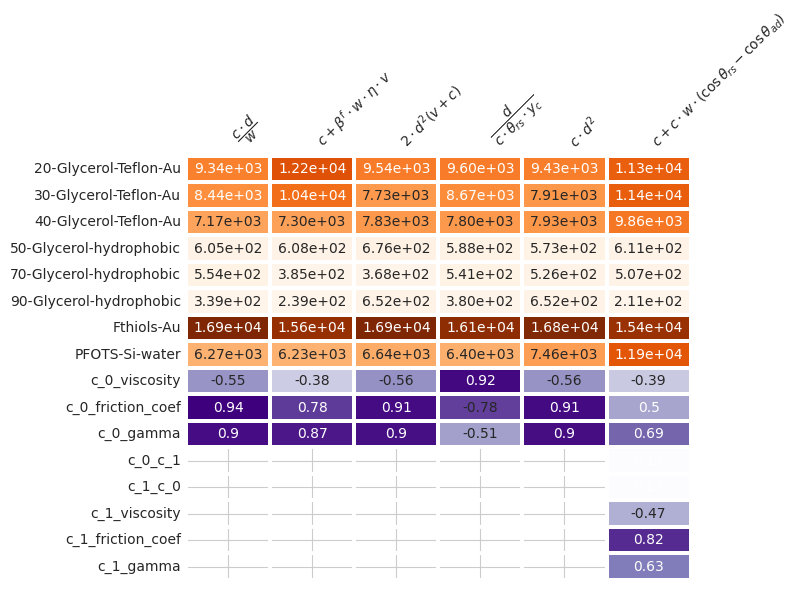

In [28]:
from src.analyse_equations.create_constant_table import add_fitted_constants, add_given_constants, calculate_correlations
import numpy as np
import pandas as pd
import seaborn as sns
indices = [174, 4, 29 ,87, 39, 5]
metric = 'err_rel'





pd_dict = heatmap_error_per_system(
        all_data_dfs,
        args,
        df_error,
        proposed_equations,
        indices,
        metric
    )
pd.DataFrame(pd_dict)
save_system_error_heatmap(args, pd_dict)

### Create constant table

In [9]:
index = 174
pd_constants = create_constant_table(
    all_data_dfs,
    args,
    df_error.loc[index].loc['equation'],
    proposed_equations
)
save_constant_table(args, logger, pd_constants)
pd_constants

INFO:__main__:table with constants saved @ /home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/plots/ID_error_per_dataset/table_with_constants.tex


,c_0,viscosity,friction_coef,gamma
20-Glycerol-Teflon-Au,8.16e-05,1.70e-03,5.90e+01,7.00e-02
30-Glycerol-Teflon-Au,8.59e-05,2.50e-03,5.60e+01,6.90e-02
40-Glycerol-Teflon-Au,9.91e-05,3.80e-03,4.10e+01,6.90e-02
50-Glycerol-hydrophobic,1.28e-06,1.42e-01,2.55e-02,6.80e-02
70-Glycerol-hydrophobic,2.57e-06,1.78e-02,5.08e-01,6.60e-02
90-Glycerol-hydrophobic,4.76e-06,5.97e-03,1.16e+01,6.50e-02
Fthiols-Au,1.20e-04,9.20e-04,5.60e+01,7.20e-02
PFOTS-Si-water,1.36e-04,9.20e-04,9.60e+01,7.20e-02
corr_c0,1.00e+00,-5.51e-01,9.37e-01,9.03e-01


## Print units

In [10]:
index = 174
print_units_of_one_equation(args, df_error, index, proposed_equations)

INFO:src.analyse_equations.analyse_equations:('y', '( c_0 * (  ( drop_length )  /  ( width )  )  ) ')


d: 0  id: 0.0   *	 m^1.0 * s^-2.0 * kg^1.0
d: 1  id: 1.0   	c_0	 m^1.0 * s^-2.0 * kg^1.0
d: 1  id: 512.0 	/	 
d: 2  id: 513.0 		drop_length	 m^1.0
d: 2  id: 768.0 		width	 m^1.0


In [11]:
# Plot prediction

Saving prediction plot to: /home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/plots/ID_error_per_dataset/equations/prediction_( c_0 +  ( c_1 * (  ( width )  * (  cos ( ( rec )  ) -  cos ( ( adv )  ) )  )  )  ) .pdf


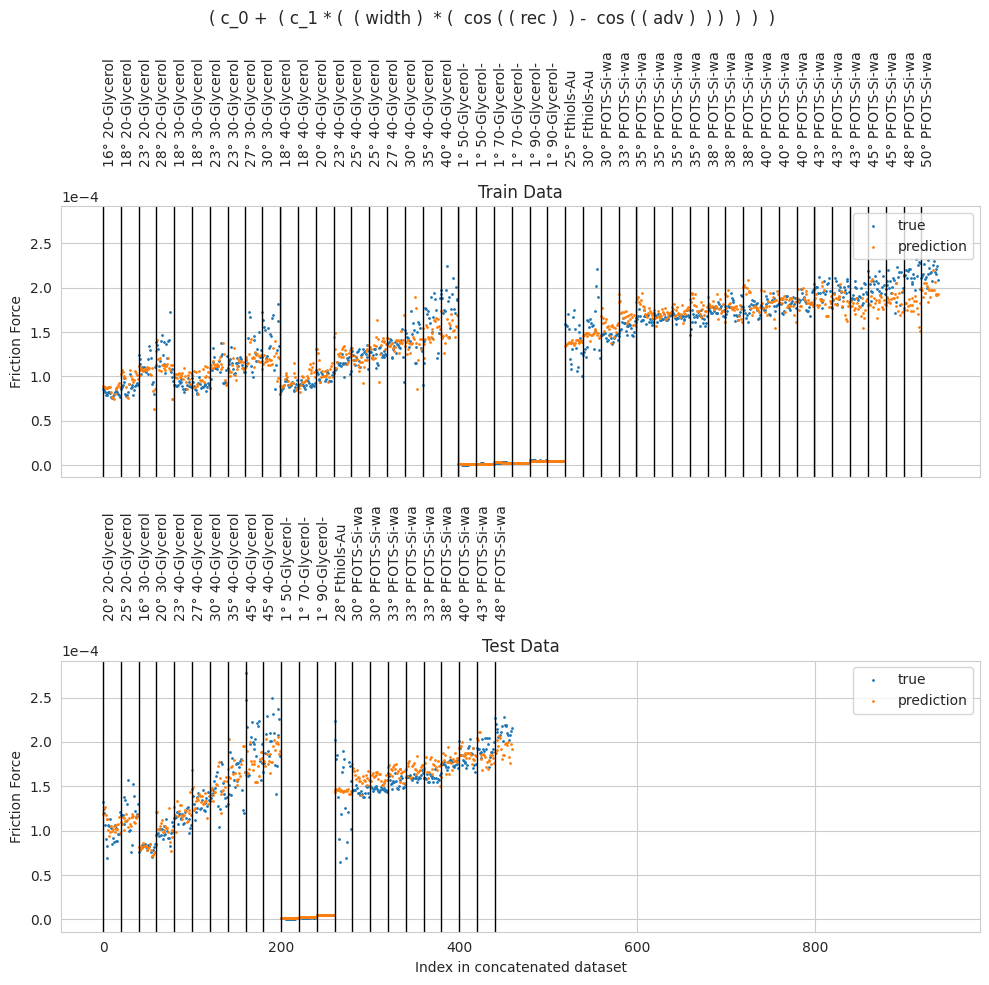

In [34]:
index =5
equation = proposed_equations[df_error.loc[index].loc['equation']]
tree = map_equation_to_syntax_tree(args, df_error.loc[index].loc['equation'], infix=False, catch_exceptions=False)
tree.constants_in_tree = equation['all_data']['train']['constants']
plot_prediction(args, filtered_dfs_test, filtered_dfs_train, tree)

## Error per system

/home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/src/analyse_equations/plot_error_per_system.py:49: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


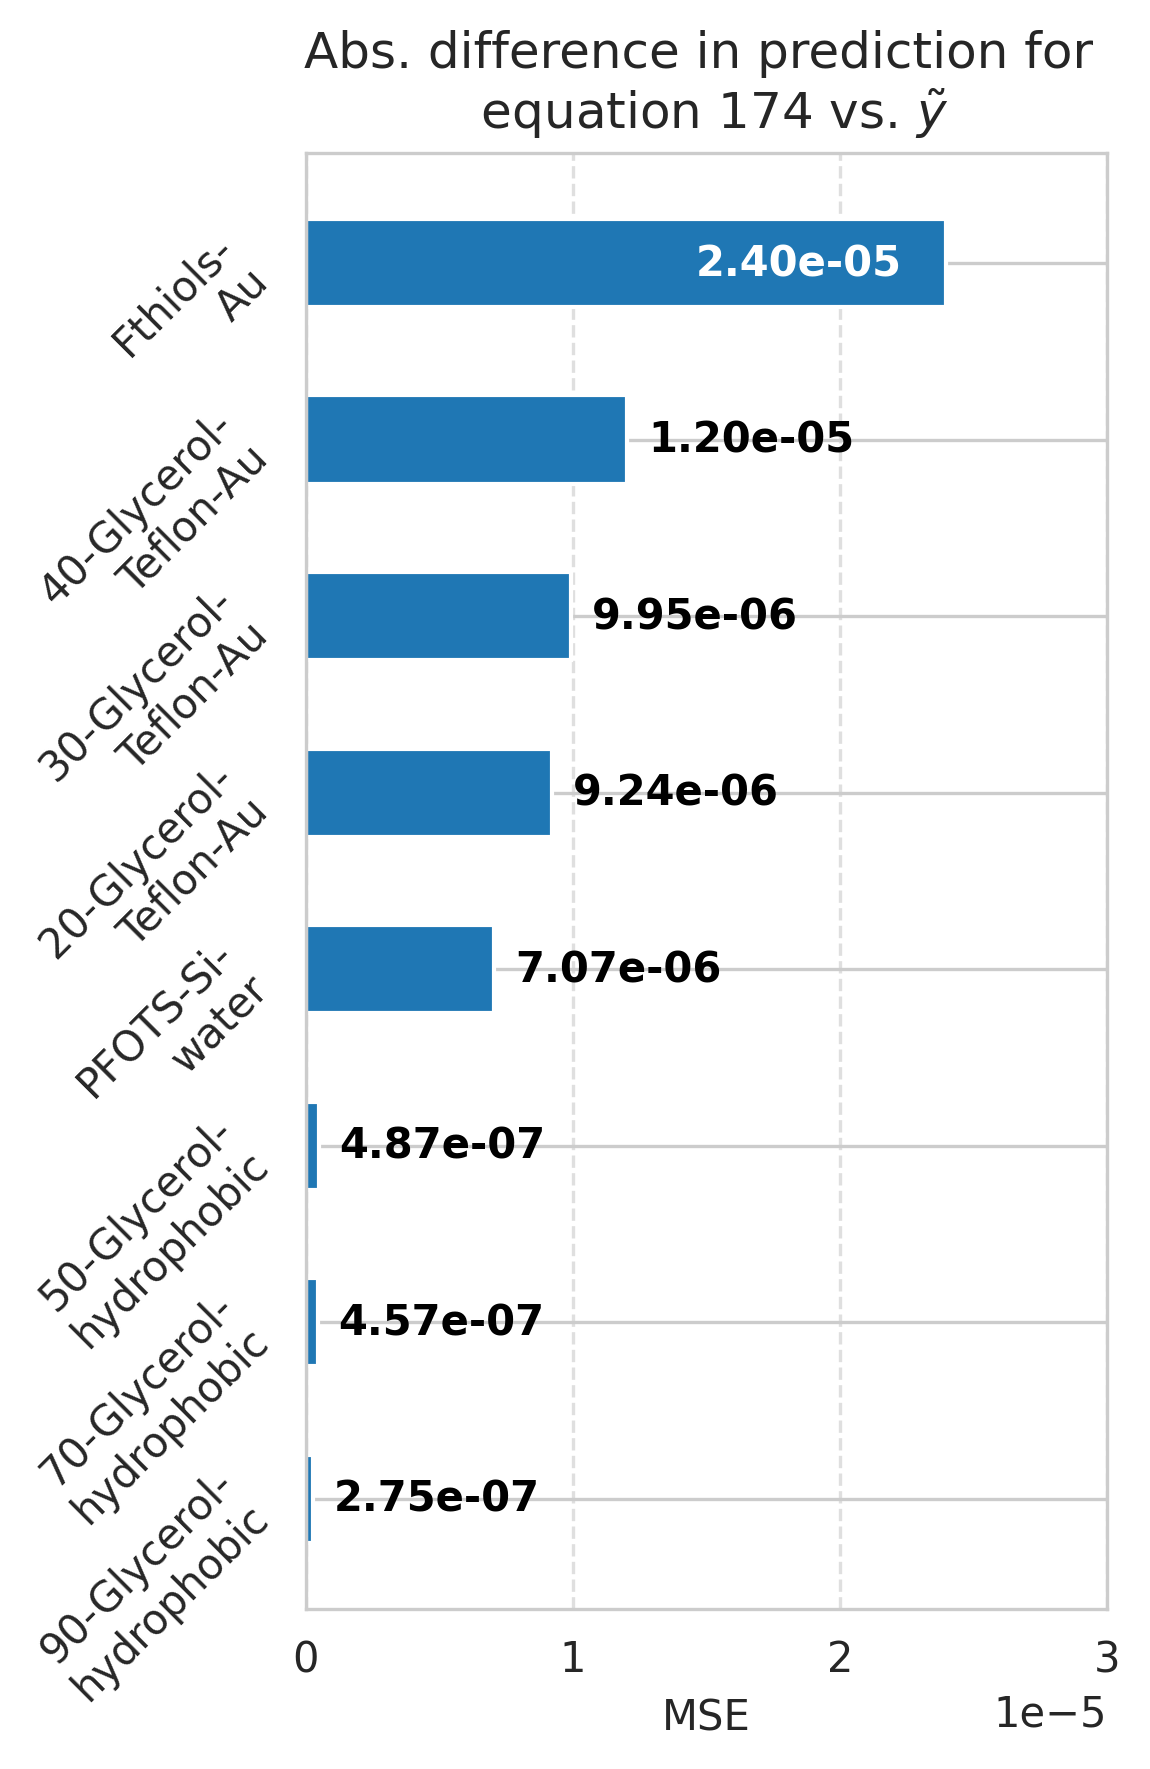

In [13]:
index = 174
plot_error_per_system(args, df_error, index, proposed_equations)

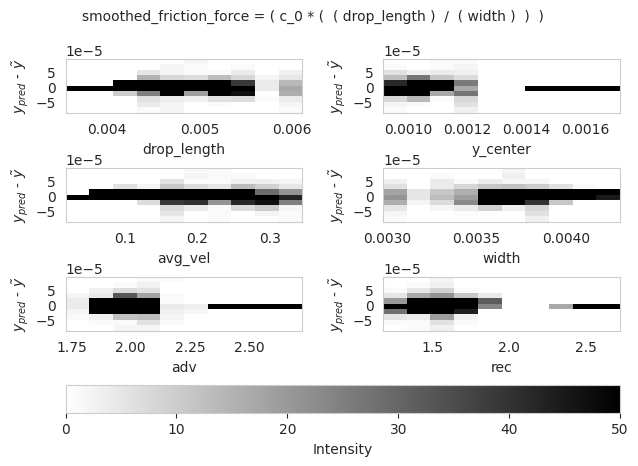

In [14]:
import math
import traceback


########################################
############ histogram #############
########################################
args.features = ['drop_length', 'y_center','avg_vel', 'width','adv', 'rec']


index = 174
equation = proposed_equations[df_error.loc[index].loc['equation']]
tree = map_equation_to_syntax_tree(args, df_error.loc[index].loc['equation'], infix=False, catch_exceptions=False)
tree.constants_in_tree = equation['all_data']['train']['constants']
histogram_for_features(args, all_data_dfs, tree)

/home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/src/analyse_equations/plot_abs_difference_between_equation.py:58: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


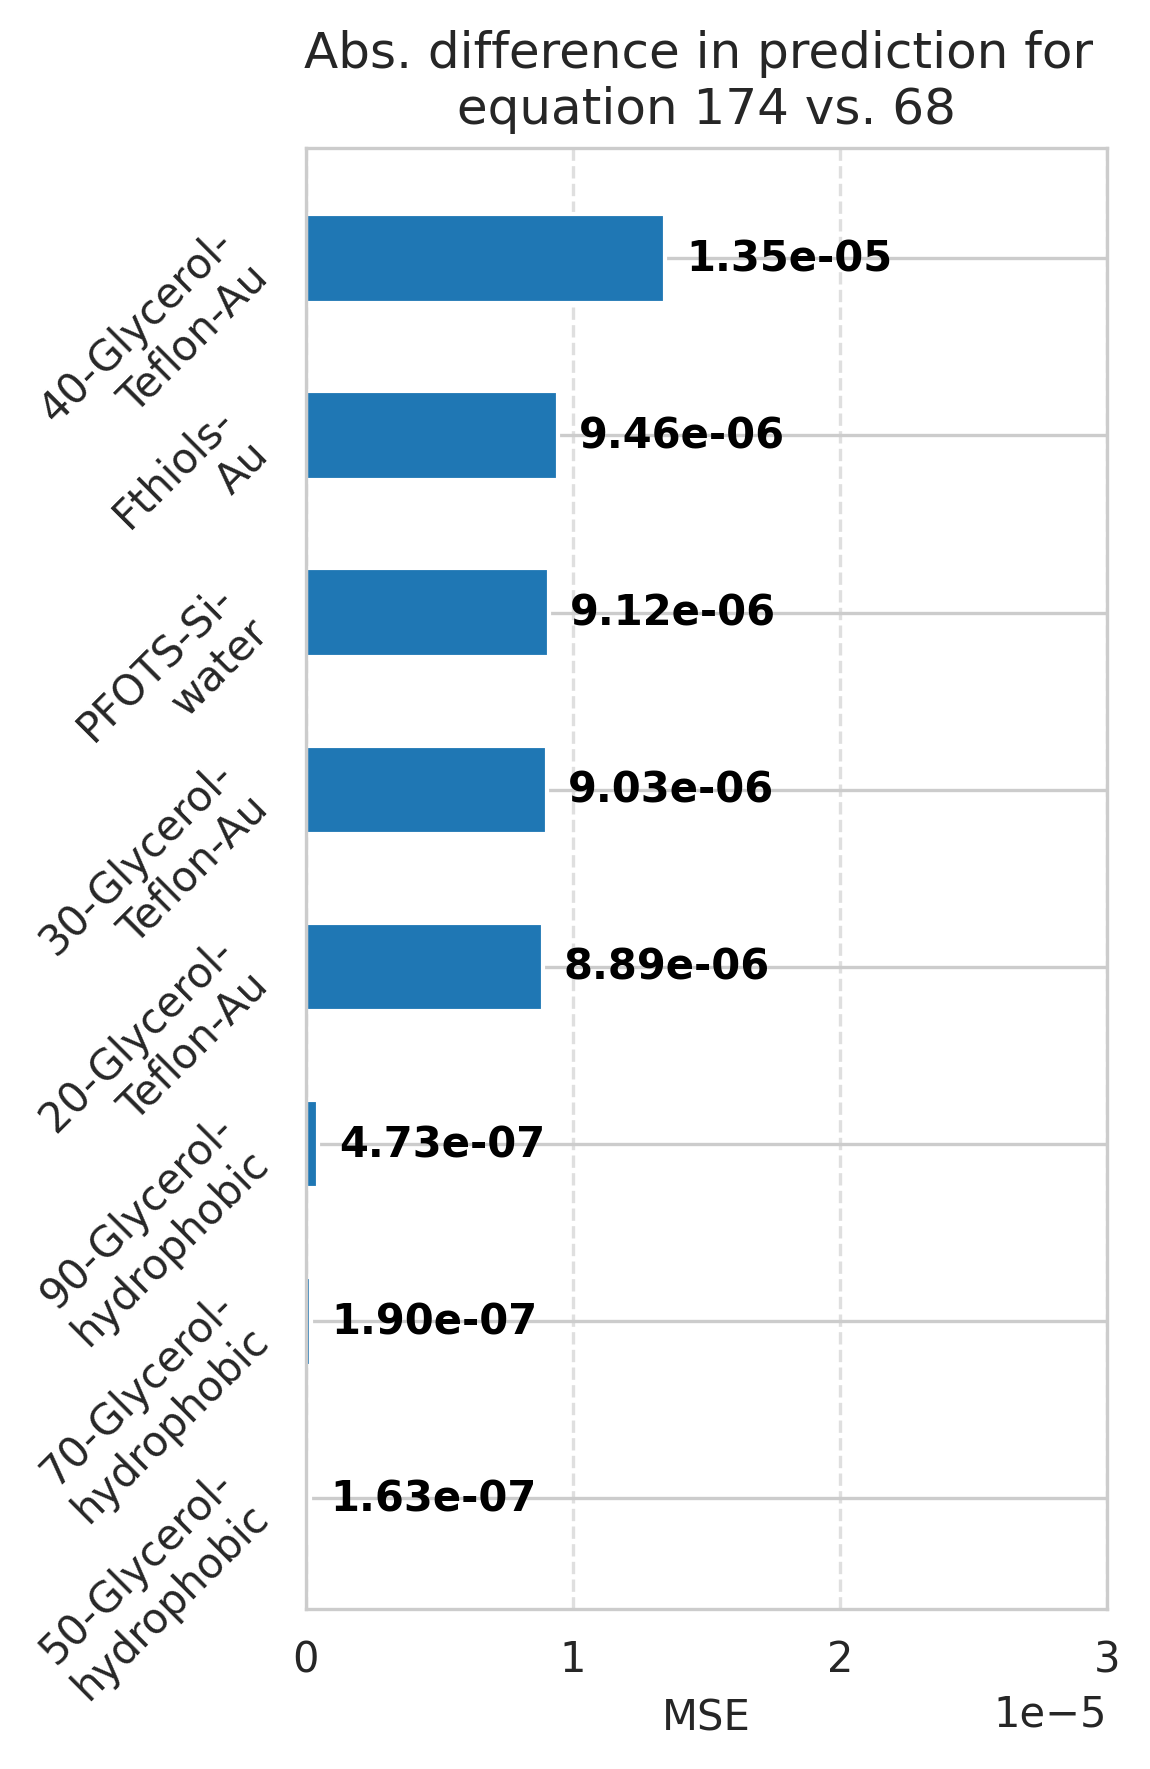

In [15]:
########################################
###### difference between two eq #######
########################################
index_0 = 174
index_1 = 68
abs_difference_between_equation(args, proposed_equations, df_error, all_data_dfs, index_0, index_1)
